# Adult Income Prediction

Цель проекта — предсказать, превышает ли годовой доход человека 50 000 долларов, по данным переписи населения США.

In [1]:
import pandas as pd
from pathlib import Path

## 1. Загрузка данных

Использую датасет Adult Income из UCI. Данные находятся в `data/raw/adult.data`.

In [2]:
column_names = ["age", "workclass", "fnlwgt", "education", "education_num", "marital_status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]

In [3]:
df = pd.read_csv("../data/raw/adult.data", names=column_names, header=None, skipinitialspace=True)

## 2. Первичный анализ данных

Проверю размер датасета, типы признаков, распределение целевой переменной, пропуски и дубликаты.

In [4]:
df.head(10)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [5]:
df.shape

(32561, 15)

In [6]:
df["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [8]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [9]:
(df == "?").sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(24)

In [11]:
df["income"].value_counts()
df["income"].value_counts(normalize=True)

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

## 3. Очистка данных

В датасете пропуски обозначены символом `?`. Заменяю его на стандартное значение `NaN`, чтобы затем корректно обработать пропуски.

In [12]:
df["workclass"] = df["workclass"].replace("?", pd.NA)
df["occupation"] = df["occupation"].replace("?", pd.NA)
df["native-country"] = df["native-country"].replace("?", pd.NA)

In [13]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

## 4. Подготовка целевой переменной

Преобразую значения дохода в бинарный формат: `<=50K` — 0, `>50K` — 1.

In [14]:
df["income"].unique()

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str

In [15]:
df["income"] = df["income"].replace("<=50K", 0)
df["income"] = df["income"].replace(">50K", 1)

In [16]:
df["income"].unique()

array([0, 1], dtype=object)

In [17]:
df["income"].value_counts()

income
0    24720
1     7841
Name: count, dtype: int64

## 5. Выбор признаков

Исключаю `fnlwgt`, так как это технический вес наблюдения, и `education`, поскольку его смысл уже отражает числовой признак `education_num`.

In [18]:
numerical_features = ["age", "education_num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_features = ["workclass", "marital_status", "occupation", "relationship", "race", "sex", "native-country"]

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X = df[numerical_features + categorical_features]

In [21]:
y = df["income"].astype(int)

## 6. Разделение на обучающую и тестовую выборки

Отделяю 20% данных для финальной проверки модели. Использую стратификацию, чтобы сохранить соотношение классов.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [23]:
y_train.value_counts(normalize=True)

income
0    0.759175
1    0.240825
Name: proportion, dtype: float64

In [24]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## 7. Предобработка признаков

Числовые пропуски заполняются медианой. Категориальные — наиболее частым значением, после чего категории кодируются методом One-Hot Encoding.

In [25]:
num_transformer = SimpleImputer(strategy='median')

cat_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('OneHot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_features),
        ('cat', cat_transformer, categorical_features)
    ])

In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

## 8. Базовая модель

Сначала проверяю DummyClassifier. Он всегда выбирает самый частый класс и показывает минимальный ориентир качества.

In [27]:
model_dum = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model_dum)])

In [28]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [29]:
dummy_f1_scores = cross_val_score(
    dummy_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

In [30]:
dummy_f1_scores

array([0., 0., 0., 0., 0.])

In [31]:
dummy_f1_scores.mean()

np.float64(0.0)

In [32]:
dummy_f1_scores.std()

np.float64(0.0)

In [33]:
from sklearn.ensemble import RandomForestClassifier

## 9. Random Forest

Обучаю Random Forest и оцениваю качество с помощью 5-fold cross-validation. Основная метрика — F1-score.

In [34]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

In [35]:
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', rf_model)])

In [36]:
rf_f1_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

In [37]:
rf_f1_scores

array([0.63975694, 0.67458634, 0.65617021, 0.67226891, 0.66580977])

In [38]:
rf_f1_scores.mean()

np.float64(0.6617184343953866)

In [39]:
rf_f1_scores.std()

np.float64(0.012702159358156623)

In [40]:
from xgboost import XGBClassifier

## 10. XGBoost

Обучаю XGBoost и сравниваю его результаты с базовой моделью и Random Forest.

In [41]:
xgb_model = XGBClassifier(n_estimators = 300, random_state = 42, eval_metric = 'logloss', n_jobs = -1)

In [42]:
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', xgb_model)])

In [43]:
xgb_f1_scores = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)


In [44]:
print(xgb_f1_scores, xgb_f1_scores.mean(), xgb_f1_scores.std())

[0.6847079  0.71501272 0.71179225 0.71272115 0.7019475 ] 0.7052363052621886 0.011196545050947627


## 11. Финальная оценка лучшей модели

Выбираю XGBoost как лучшую модель по F1-score, обучаю её на тренировочной выборке и оцениваю на отложенной тестовой выборке.

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [46]:
xgb_pipeline.fit(X_train, y_train)

y_pred = xgb_pipeline.predict(X_test)

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["<=50K", ">50K"]
    )
)

confusion_matrix(y_test, y_pred)

Accuracy: 0.8701059419622293
Precision: 0.7567567567567568
Recall: 0.6785714285714286
F1: 0.7155346334902488

Classification report:
              precision    recall  f1-score   support

       <=50K       0.90      0.93      0.92      4945
        >50K       0.76      0.68      0.72      1568

    accuracy                           0.87      6513
   macro avg       0.83      0.80      0.82      6513
weighted avg       0.87      0.87      0.87      6513



array([[4603,  342],
       [ 504, 1064]])

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## 12. Сравнение моделей

Сравниваю модели по средним значениям F1-score и accuracy на кросс-валидации.

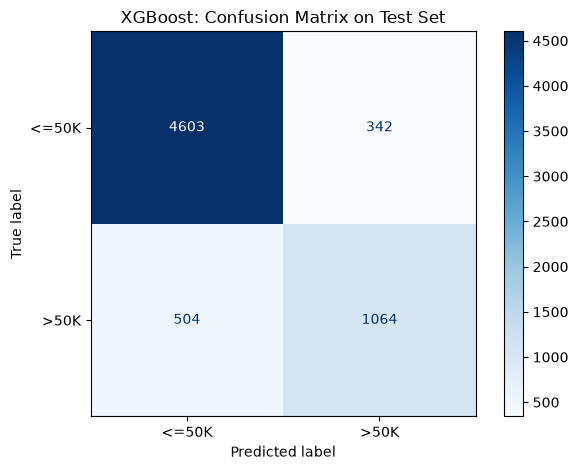

In [49]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

display.plot(cmap="Blues", values_format="d")
plt.title("XGBoost: Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()

In [50]:
dummy_accuracy_scores = cross_val_score(
    dummy_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

In [51]:
rf_accuracy_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

In [52]:
xgb_accuracy_scores = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

In [53]:
model_metrics = pd.DataFrame(
    {
        "model": ["Dummy", "Random Forest", "XGBoost"],
        "f1_mean": [
            dummy_f1_scores.mean(),
            rf_f1_scores.mean(),
            xgb_f1_scores.mean()
        ],
        "f1_std": [
            dummy_f1_scores.std(),
            rf_f1_scores.std(),
            xgb_f1_scores.std()
        ],
        "accuracy_mean": [
            dummy_accuracy_scores.mean(),
            rf_accuracy_scores.mean(),
            xgb_accuracy_scores.mean()
        ],
        "accuracy_std": [
            dummy_accuracy_scores.std(),
            rf_accuracy_scores.std(),
            xgb_accuracy_scores.std()
        ]
    }
)

model_metrics

,model,f1_mean,f1_std,accuracy_mean,accuracy_std
0,Dummy,0.000000,0.000000,0.759175,0.000071
1,Random Forest,0.661718,0.012702,0.847781,0.004377
2,XGBoost,0.705236,0.011197,0.866823,0.004391


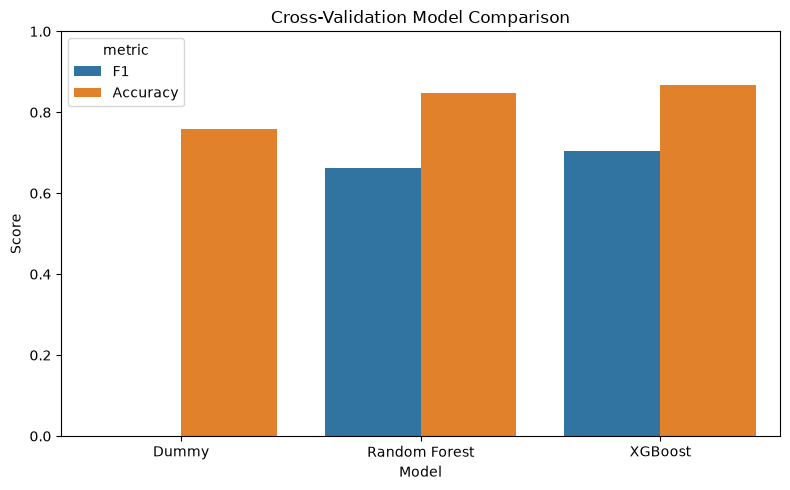

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_metrics = model_metrics.melt(
    id_vars="model",
    value_vars=["f1_mean", "accuracy_mean"],
    var_name="metric",
    value_name="score"
)

plot_metrics["metric"] = plot_metrics["metric"].replace(
    {
        "f1_mean": "F1",
        "accuracy_mean": "Accuracy"
    }
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=plot_metrics,
    x="model",
    y="score",
    hue="metric"
)

plt.ylim(0, 1)
plt.title("Cross-Validation Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [55]:
# Save the cross-validation comparison table
from pathlib import Path

tables_dir = Path("../reports/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

model_metrics.to_csv(tables_dir / "model_metrics.csv", index=False)
print("Saved: reports/tables/model_metrics.csv")


Saved: reports/tables/model_metrics.csv


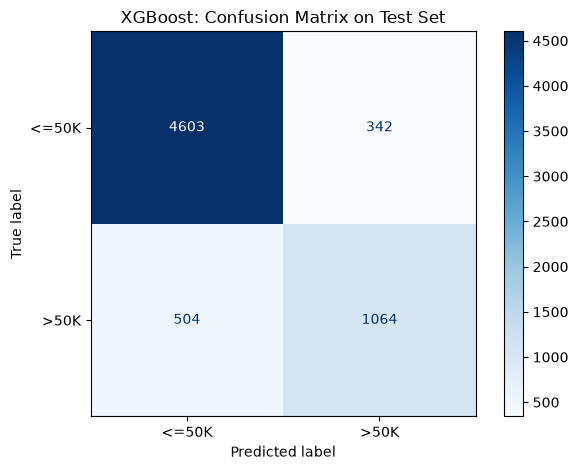

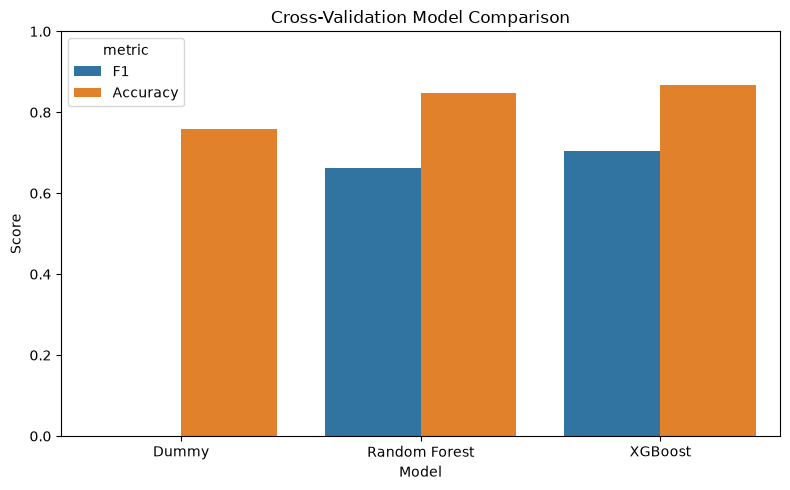

Saved: reports/figures/xgboost_confusion_matrix.png
Saved: reports/figures/model_comparison_cv.png


In [56]:
# Save the required figures
figures_dir = Path("../reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=["<=50K", ">50K"]
)
cm_display.plot(cmap="Blues", values_format="d")
plt.title("XGBoost: Confusion Matrix on Test Set")
plt.tight_layout()
plt.savefig(figures_dir / "xgboost_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_metrics, x="model", y="score", hue="metric")
plt.ylim(0, 1)
plt.title("Cross-Validation Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(figures_dir / "model_comparison_cv.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: reports/figures/xgboost_confusion_matrix.png")
print("Saved: reports/figures/model_comparison_cv.png")


## Выводы

XGBoost показал лучший F1-score среди проверенных моделей. Accuracy сама по себе недостаточна из-за дисбаланса классов, поэтому основным критерием выбора модели был F1-score.

Ограничение проекта: результат отражает закономерности исторических данных и не должен использоваться для реальных решений о найме, кредитовании или доступе к услугам.